# **Importing Libraries**

Importing libraries in Python enables access to pre-written functions, classes, and modules, which streamline tasks like data manipulation, visualization, and machine learning, allowing for efficient and organized coding.


In [65]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




# **Read Data**

First let's read datas and take a look at the data we have



In [66]:
# Load the dataset
file_path = "Solar Energy.csv"  # Update this path if needed
df = pd.read_csv(file_path)

<ipython-input-66-6cc1a0a28e55>:3: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


# **An overview of data **

In [67]:
# Display first 5 rows to understand structure
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


In [68]:
# Display dataset shape
print(f"\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")


Dataset contains 218115 rows and 17 columns.


In [69]:
# Display column names
print("\nColumn Names:")
print(df.columns)



Column Names:
Index(['Data Through Date', 'Project ID', 'Interconnection Date', 'Utility',
       'City/Town', 'County', 'Zip', 'Division', 'Substation', 'Circuit ID',
       'Developer', 'Metering Method', 'Estimated PV System Size (kWdc)',
       'PV System Size (kWac)', 'Estimated Annual PV Energy Production (kWh)',
       'Energy Storage System Size (kWac)', 'Number of Projects'],
      dtype='object')


In [70]:
# Display data types of each column
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
Data Through Date                               object
Project ID                                      object
Interconnection Date                            object
Utility                                         object
City/Town                                       object
County                                          object
Zip                                            float64
Division                                        object
Substation                                      object
Circuit ID                                      object
Developer                                       object
Metering Method                                 object
Estimated PV System Size (kWdc)                float64
PV System Size (kWac)                          float64
Estimated Annual PV Energy Production (kWh)      int64
Energy Storage System Size (kWac)              float64
Number of Projects                               int64
dtype: object


# **Check for missing values**

In [71]:
# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
Data Through Date                                   0
Project ID                                          3
Interconnection Date                                0
Utility                                             0
City/Town                                          58
County                                              0
Zip                                                96
Division                                        85234
Substation                                      79944
Circuit ID                                         30
Developer                                       10550
Metering Method                                   463
Estimated PV System Size (kWdc)                     0
PV System Size (kWac)                               0
Estimated Annual PV Energy Production (kWh)         0
Energy Storage System Size (kWac)              214024
Number of Projects                                  0
dtype: int64


In [72]:
# Convert date columns to datetime format
df['Data Through Date'] = pd.to_datetime(df['Data Through Date'], errors='coerce')
df['Interconnection Date'] = pd.to_datetime(df['Interconnection Date'], errors='coerce')
# Verify that date columns are in datetime format
df[['Data Through Date', 'Interconnection Date']].dtypes


,0
Data Through Date,datetime64[ns]
Interconnection Date,datetime64[ns]


# **Check for duplicate rows**

In [73]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")


Number of duplicate rows: 0


In [74]:
# Display basic statistical summary of numerical columns
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Data Through Date,Interconnection Date,Zip,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
count,218115,218115,218019.000000,218115.000000,218115.000000,2.181150e+05,4091.000000,218115.0
mean,2023-12-31 00:00:00,2018-08-09 13:04:35.056736256,11751.734473,24.507977,19.065451,2.876828e+04,32.174727,1.0
min,2023-12-31 00:00:00,2000-12-21 00:00:00,10001.000000,0.010000,0.010000,1.400000e+01,0.350000,1.0
25%,2023-12-31 00:00:00,2015-12-30 00:00:00,11220.000000,5.270000,4.500000,6.180000e+03,5.000000,1.0
50%,2023-12-31 00:00:00,2018-08-17 00:00:00,11717.000000,7.130000,6.090000,8.364000e+03,7.600000,1.0
75%,2023-12-31 00:00:00,2021-12-09 00:00:00,12018.000000,10.240000,8.750000,1.201700e+04,10.000000,1.0
max,2023-12-31 00:00:00,2023-12-29 00:00:00,14905.000000,43470.000000,31500.000000,5.102682e+07,5000.000000,1.0
std,NaN,NaN,962.129108,291.525394,211.419642,3.422042e+05,296.161116,0.0


In [75]:
# Identify categorical and numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [76]:
# Handling missing values in numerical columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)  # Using median for robustness

<ipython-input-76-ffb4c9a65498>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)  # Using median for robustness


In [77]:
# Fill missing values with 'Unknown'
categorical_cols = ['Project ID', 'City/Town', 'Division', 'Substation', 'Developer',
                    'Metering Method', 'Circuit ID', 'Zip', 'Utility', 'County']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [78]:
# Convert categorical variables to strings
df[categorical_cols] = df[categorical_cols].astype(str)

In [79]:
# Verify if there are any missing values left
print(df.isnull().sum())


Data Through Date                              0
Project ID                                     0
Interconnection Date                           0
Utility                                        0
City/Town                                      0
County                                         0
Zip                                            0
Division                                       0
Substation                                     0
Circuit ID                                     0
Developer                                      0
Metering Method                                0
Estimated PV System Size (kWdc)                0
PV System Size (kWac)                          0
Estimated Annual PV Energy Production (kWh)    0
Energy Storage System Size (kWac)              0
Number of Projects                             0
dtype: int64


In [80]:
# Label Encoding for high-cardinality categorical columns
label_enc_cols = ['Project ID', 'Zip', 'Circuit ID']
label_encoders = {}
for col in label_enc_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoder for inverse transformation if needed

# Frequency Encoding for remaining categorical variables
freq_enc_cols = ['Utility', 'City/Town', 'County', 'Division', 'Substation', 'Developer', 'Metering Method']
for col in freq_enc_cols:
    df[col] = df[col].map(df[col].value_counts(normalize=True))  # Replace category with its frequency

In [81]:
# Display first few rows of the transformed dataset
df.head()

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,2023-12-31,218076,2023-12-29,0.296674,0.001059,0.105495,309,0.054934,0.024249,5873,0.012393,0.986599,6.05,5.17,7100,7.6,1
1,2023-12-31,218075,2023-12-29,0.296674,0.014025,0.027197,74,0.027169,0.013736,4590,0.012393,0.986599,6.74,5.76,7911,7.6,1
2,2023-12-31,218074,2023-12-29,0.296674,0.026275,0.054769,260,0.054934,0.016157,3984,0.011599,0.986599,3.05,2.61,3585,7.6,1
3,2023-12-31,218073,2023-12-29,0.296674,0.026275,0.054769,270,0.054934,0.016157,1568,0.012393,0.986599,5.62,4.80,6592,7.6,1
4,2023-12-31,218072,2023-12-28,0.296674,0.006987,0.105495,304,0.100007,0.053096,5783,0.012393,0.986599,6.05,5.17,7100,7.6,1


# **Exploratory Data Analysis (EDA)**

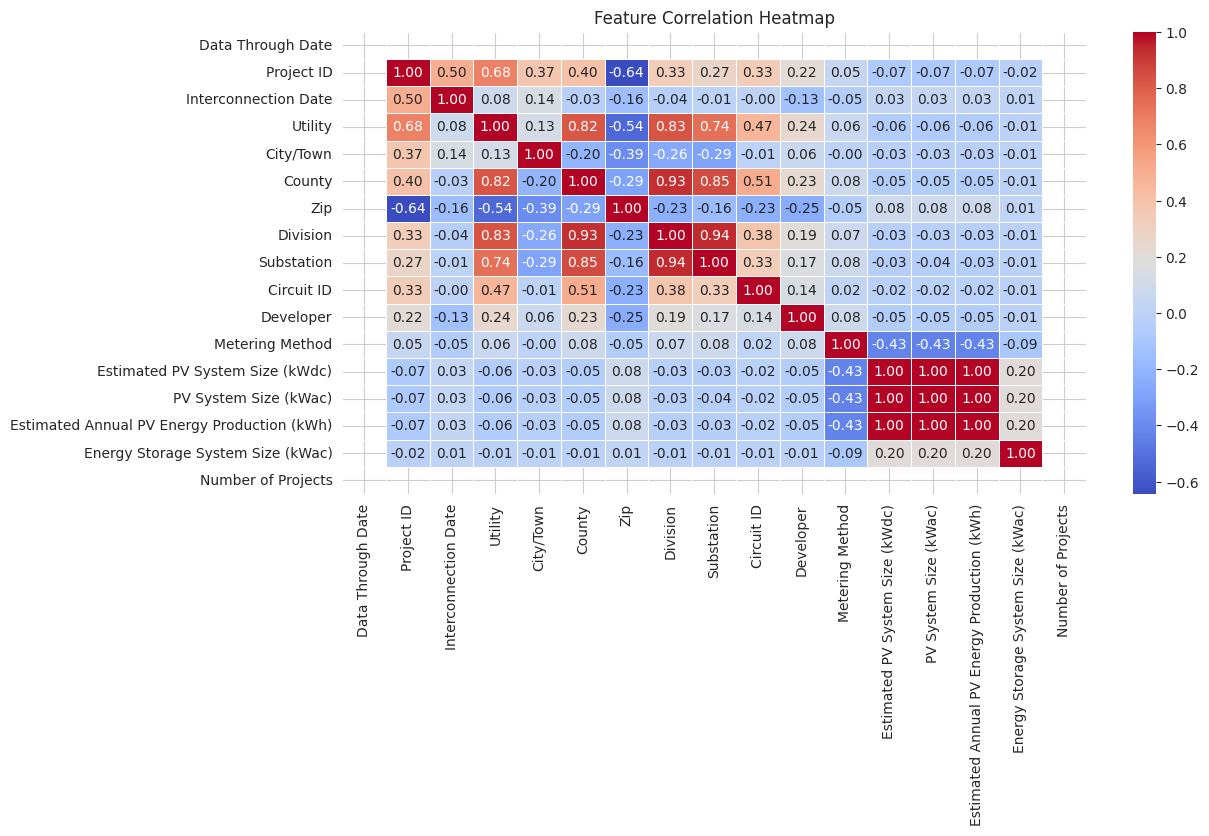

In [82]:
# Set plot style
sns.set_style("whitegrid")
# 1 Correlation Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

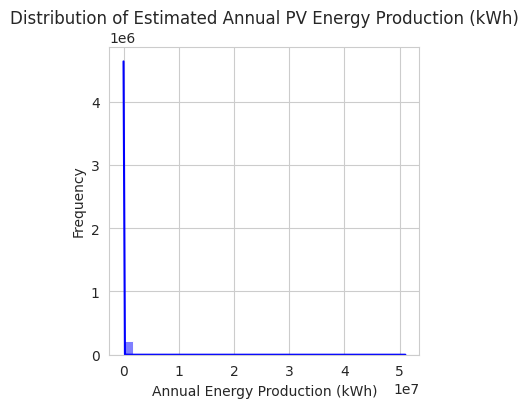

In [83]:
# 2️ Distribution of the Target Variable
plt.figure(figsize=(4, 4))
sns.histplot(df["Estimated Annual PV Energy Production (kWh)"], bins=30, kde=True, color='blue')
plt.title("Distribution of Estimated Annual PV Energy Production (kWh)")
plt.xlabel("Annual Energy Production (kWh)")
plt.ylabel("Frequency")
plt.show()

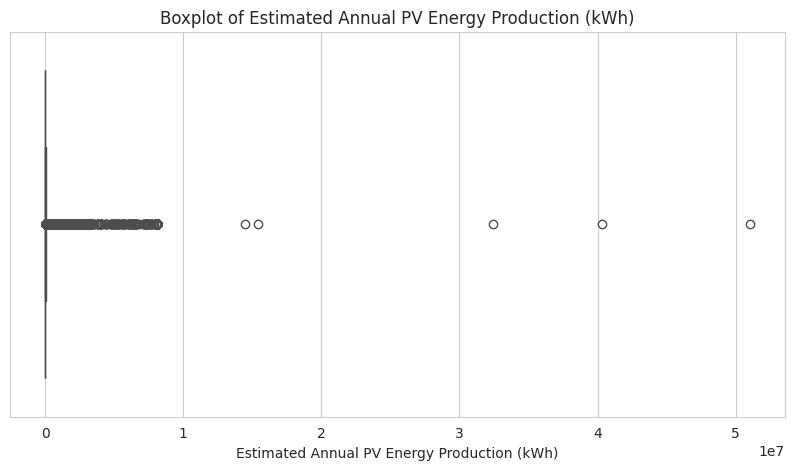

In [84]:

# 3️ Boxplot for Outlier Detection
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Estimated Annual PV Energy Production (kWh)"], color='red')
plt.title("Boxplot of Estimated Annual PV Energy Production (kWh)")
plt.show()

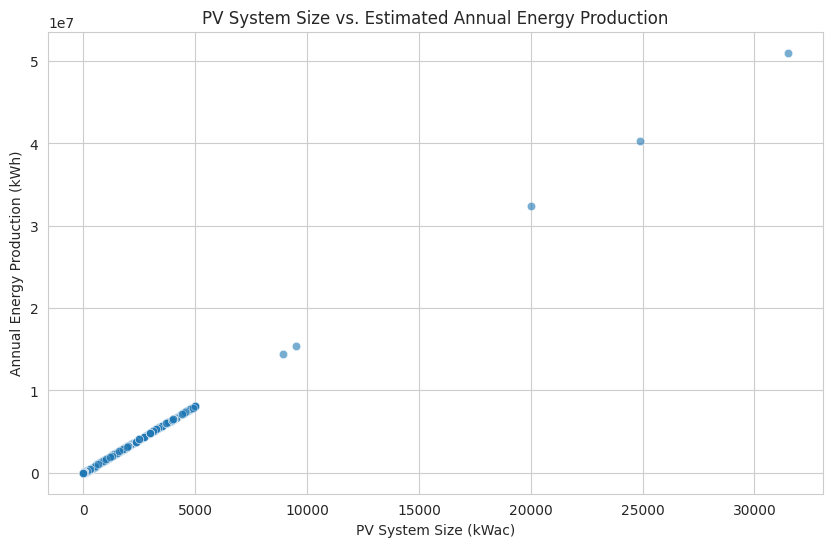

In [85]:
# 4️ Relationship Between PV System Size & Energy Production
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["PV System Size (kWac)"], y=df["Estimated Annual PV Energy Production (kWh)"], alpha=0.6)
plt.title("PV System Size vs. Estimated Annual Energy Production")
plt.xlabel("PV System Size (kWac)")
plt.ylabel("Annual Energy Production (kWh)")
plt.show()


In [86]:
df = df.drop(columns=['Interconnection Date'])
df = df.drop(columns=['Data Through Date'])

In [87]:
# Show the first few rows
display(df.head())

,Project ID,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,218076,0.296674,0.001059,0.105495,309,0.054934,0.024249,5873,0.012393,0.986599,6.05,5.17,7100,7.6,1
1,218075,0.296674,0.014025,0.027197,74,0.027169,0.013736,4590,0.012393,0.986599,6.74,5.76,7911,7.6,1
2,218074,0.296674,0.026275,0.054769,260,0.054934,0.016157,3984,0.011599,0.986599,3.05,2.61,3585,7.6,1
3,218073,0.296674,0.026275,0.054769,270,0.054934,0.016157,1568,0.012393,0.986599,5.62,4.80,6592,7.6,1
4,218072,0.296674,0.006987,0.105495,304,0.100007,0.053096,5783,0.012393,0.986599,6.05,5.17,7100,7.6,1


In [88]:


# Define target variable
target_variable = "Estimated Annual PV Energy Production (kWh)"

# Compute correlation matrix
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop (excluding target variable)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90) and column != target_variable]

# Drop the selected features
df_cleaned = df.drop(columns=to_drop)

print("Dropped columns:", to_drop)
print("Remaining columns:", df_cleaned.columns)


Dropped columns: ['Division', 'Substation', 'PV System Size (kWac)']
Remaining columns: Index(['Project ID', 'Utility', 'City/Town', 'County', 'Zip', 'Circuit ID',
       'Developer', 'Metering Method', 'Estimated PV System Size (kWdc)',
       'Estimated Annual PV Energy Production (kWh)',
       'Energy Storage System Size (kWac)', 'Number of Projects'],
      dtype='object')


In [89]:
df_cleaned.head()

,Project ID,Utility,City/Town,County,Zip,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,218076,0.296674,0.001059,0.105495,309,5873,0.012393,0.986599,6.05,7100,7.6,1
1,218075,0.296674,0.014025,0.027197,74,4590,0.012393,0.986599,6.74,7911,7.6,1
2,218074,0.296674,0.026275,0.054769,260,3984,0.011599,0.986599,3.05,3585,7.6,1
3,218073,0.296674,0.026275,0.054769,270,1568,0.012393,0.986599,5.62,6592,7.6,1
4,218072,0.296674,0.006987,0.105495,304,5783,0.012393,0.986599,6.05,7100,7.6,1


# **Machine Learning Model Development**

In [92]:


# Separate features (X) and target variable (y)
X = df_cleaned.drop(columns=['Estimated Annual PV Energy Production (kWh)'])  # Replace with actual target column name
y = df_cleaned['Estimated Annual PV Energy Production (kWh)']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features for Linear Regression & SVR (not needed for tree-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42),

}

# Train, predict, and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    if name in ["Linear Regression"]:
        model.fit(X_train_scaled, y_train)  # Use scaled data for Linear Regression & SVR
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 Model: {name}")
    print(f"   MAE: {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   R² Score: {r2:.2f}")



Training Linear Regression...

📊 Model: Linear Regression
   MAE: 2.40
   RMSE: 3.04
   R² Score: 1.00

Training Random Forest...

📊 Model: Random Forest
   MAE: 134.91
   RMSE: 19014.68
   R² Score: 1.00

Training XGBoost...

📊 Model: XGBoost
   MAE: 5404.17
   RMSE: 98290.42
   R² Score: 0.91

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1622
[LightGBM] [Info] Number of data points in the train set: 174492, number of used features: 10
[LightGBM] [Info] Start training from score 28729.820542

📊 Model: LightGBM
   MAE: 2621.20
   RMSE: 62520.37
   R² Score: 0.97
